In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
gdp_data=pd.read_csv('/content/gdp (1).csv')
gdp_data.sample(5)

,Country Name,Country Code,Year,Value
351,East Asia & Pacific (IDA & IBRD countries),TEA,2007,4.749075e+12
1232,Least developed countries: UN classification,LDC,2005,3.213356e+11
7731,Mauritius,MUS,1983,1.094857e+09
1691,Other small states,OSS,2004,1.507387e+11
1030,Late-demographic dividend,LTE,2006,7.436775e+12


In [ ]:
Ind_gdp=gdp_data[gdp_data['Country Name']=='India']
Ind_gdp.sample(5)

,Country Name,Country Code,Year,Value
6124,India,IND,2010,1.656617e+12
6091,India,IND,1977,1.198667e+11
6094,India,IND,1980,1.838399e+11
6074,India,IND,1960,3.653593e+10
6075,India,IND,1961,3.870910e+10


In [ ]:
Ind_gdp.isnull().sum()

,0
Country Name,0
Country Code,0
Year,0
Value,0


In [ ]:
Ind_gdp['Year'].unique()

array([1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
       1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016])

Text(0, 0.5, 'GDP')

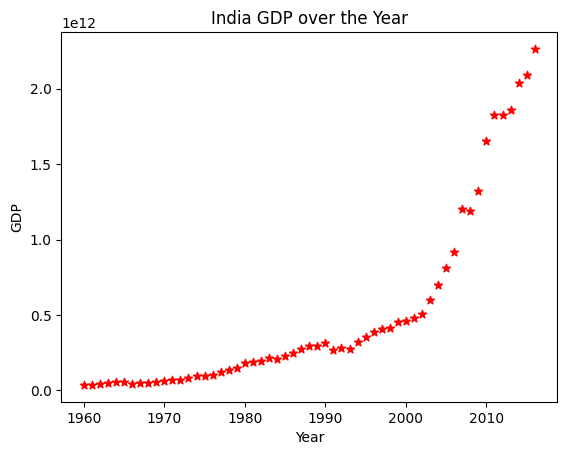

In [ ]:
plt.scatter(Ind_gdp['Year'],Ind_gdp['Value'],color='red',marker='*')
plt.title('India GDP over the Year')
plt.xlabel('Year')
plt.ylabel('GDP')

Using polynomial regression

In [ ]:
X=Ind_gdp['Year'].values.reshape(-1,1)
Y=Ind_gdp['Value'].values.reshape(-1,1)
Y


array([[3.65359250e+10],
       [3.87090961e+10],
       [4.15990702e+10],
       [4.77760009e+10],
       [5.57268731e+10],
       [5.87604247e+10],
       [4.52536413e+10],
       [4.94661689e+10],
       [5.23773243e+10],
       [5.76683300e+10],
       [6.15898005e+10],
       [6.64525619e+10],
       [7.05099130e+10],
       [8.43745416e+10],
       [9.81982769e+10],
       [9.71592220e+10],
       [1.01346972e+11],
       [1.19866747e+11],
       [1.35468783e+11],
       [1.50950827e+11],
       [1.83839865e+11],
       [1.90909549e+11],
       [1.98037713e+11],
       [2.15350771e+11],
       [2.09328157e+11],
       [2.29410294e+11],
       [2.45664654e+11],
       [2.75311425e+11],
       [2.92632656e+11],
       [2.92093308e+11],
       [3.16697338e+11],
       [2.66502281e+11],
       [2.84363884e+11],
       [2.75570363e+11],
       [3.22909902e+11],
       [3.55475984e+11],
       [3.87656018e+11],
       [4.10320300e+11],
       [4.15730874e+11],
       [4.52699998e+11],


In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
X_val

array([[1960],
       [1965],
       [1990],
       [1973],
       [1994],
       [2015],
       [1987],
       [1991],
       [2005],
       [1972],
       [2007],
       [1963]])

In [ ]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_val_scaled   = x_scaler.transform(X_val)

y_train_scaled = y_scaler.fit_transform(y_train).ravel()
y_val_scaled   = y_scaler.transform(y_val).ravel()

In [ ]:
degree = 4
poly = PolynomialFeatures(degree=degree, include_bias=True)

X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly   = poly.transform(X_val_scaled)


In [ ]:
from sklearn.linear_model import SGDRegressor

In [ ]:
model = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    alpha=1e-4,
    learning_rate="invscaling",
    eta0=0.01,
    random_state=42,
    max_iter=1,
    warm_start=True,
    tol=None
)

In [ ]:
model.partial_fit(X_train_poly, y_train_scaled)

n_epochs = 300
train_losses = []
val_losses = []

In [ ]:
for epoch in range(n_epochs):
    # one pass of SGD over training data
    model.partial_fit(X_train_poly, y_train_scaled)

    # predictions (scaled space)
    train_pred_scaled = model.predict(X_train_poly)
    val_pred_scaled   = model.predict(X_val_poly)

    # compute MSE in scaled target space
    train_mse = mean_squared_error(y_train_scaled, train_pred_scaled)
    val_mse   = mean_squared_error(y_val_scaled, val_pred_scaled)

    train_losses.append(train_mse)
    val_losses.append(val_mse)

In [ ]:
val_pred_scaled = model.predict(X_val_poly)
val_pred = y_scaler.inverse_transform(val_pred_scaled.reshape(-1, 1)).ravel()

val_mse_unscaled = mean_squared_error(y_val.ravel(), val_pred)
print(f"Validation MSE (original GDP units): {val_mse_unscaled:.6f}")

Validation MSE (original GDP units): 6074656074437929992192.000000


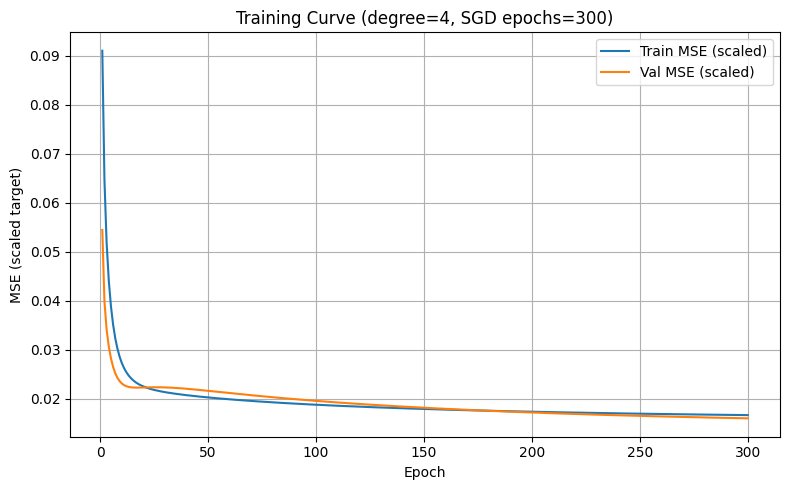

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_epochs+1), train_losses, label="Train MSE (scaled)")
plt.plot(range(1, n_epochs+1), val_losses, label="Val MSE (scaled)")
plt.xlabel("Epoch")
plt.ylabel("MSE (scaled target)")
plt.title(f"Training Curve (degree={degree}, SGD epochs={n_epochs})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
years_grid = np.linspace(Ind_gdp["Year"].min(), Ind_gdp["Year"].max(), 500).reshape(-1, 1)
years_grid_scaled = x_scaler.transform(years_grid)
years_grid_poly = poly.transform(years_grid_scaled)

gdp_pred_scaled = model.predict(years_grid_poly)
gdp_pred = y_scaler.inverse_transform(gdp_pred_scaled.reshape(-1, 1)).ravel()

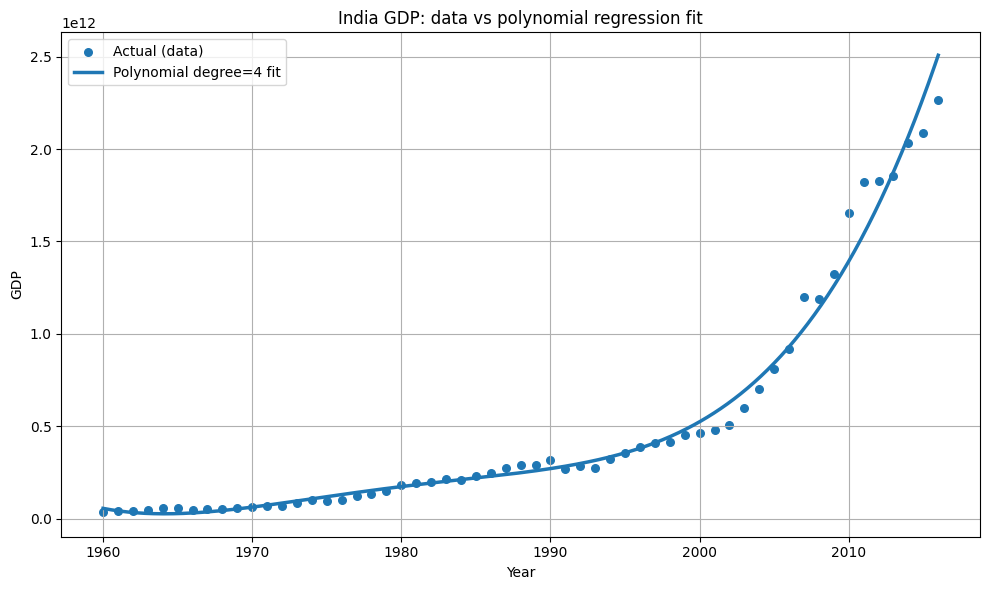

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, s=30, label="Actual (data)")
plt.plot(years_grid.ravel(), gdp_pred, linewidth=2.5, label=f"Polynomial degree={degree} fit")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.title("India GDP: data vs polynomial regression fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def predict_gdp(year):
    """ Predict GDP (original scale) for a single year (int/float). """
    year_arr = np.array([[year]])
    year_scaled = x_scaler.transform(year_arr)
    year_poly = poly.transform(year_scaled)
    pred_scaled = model.predict(year_poly)
    pred = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()[0]
    return pred

# Example
print("Predicted GDP for 2035:", predict_gdp(2020))

Predicted GDP for 2035: 3623529630026.104
